# Research Center Quality Classification

This notebook shows the full workflow for the assignment.
It covers data checks, EDA, feature selection, scaling,
clustering, interpretation, and saved outputs.

The dataset has no target label, so this is an
unsupervised learning task. K-Means is used to create
three groups, which are then named Premium, Standard,
and Basic.

In [1]:
from pathlib import Path
import json
import os
import warnings

os.environ["LOKY_MAX_CPU_COUNT"] = "1"

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="Could not find the number of physical cores.*")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

DATA_PATH = Path("research_centers.csv")
ARTIFACT_DIR = Path("artifacts")

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 50 rows x 10 columns


,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983


## 1. Data validation

Start by checking the dataset shape, column types,
and missing values.

In [3]:
print(df.shape)
print()
print(df.dtypes)
df.describe()

(50, 10)

researchCenterId            object
researchCenterName          object
city                        object
latitude                   float64
longitude                  float64
internalFacilitiesCount      int64
hospitals_10km               int64
pharmacies_10km              int64
facilityDiversity_10km     float64
facilityDensity_10km       float64
dtype: object


,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,50.542770,-1.554638,5.660000,1.860000,2.240000,0.568843,0.321164
std,0.320289,0.253853,3.146816,1.340271,1.684988,0.249511,0.182562
min,50.007100,-1.976900,1.000000,0.000000,0.000000,0.119515,0.056541
25%,50.240375,-1.747225,3.000000,1.000000,1.000000,0.344145,0.173814
50%,50.635350,-1.561000,5.000000,2.000000,2.000000,0.585503,0.297584
75%,50.831475,-1.374175,8.750000,3.000000,3.000000,0.800489,0.476387
max,50.994600,-1.049300,11.000000,4.000000,5.000000,0.992984,0.697016


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   researchCenterId         50 non-null     object 
 1   researchCenterName       50 non-null     object 
 2   city                     50 non-null     object 
 3   latitude                 50 non-null     float64
 4   longitude                50 non-null     float64
 5   internalFacilitiesCount  50 non-null     int64  
 6   hospitals_10km           50 non-null     int64  
 7   pharmacies_10km          50 non-null     int64  
 8   facilityDiversity_10km   50 non-null     float64
 9   facilityDensity_10km     50 non-null     float64
dtypes: float64(4), int64(3), object(3)
memory usage: 4.0+ KB


In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Missing values per column:
researchCenterId           0
researchCenterName         0
city                       0
latitude                   0
longitude                  0
internalFacilitiesCount    0
hospitals_10km             0
pharmacies_10km            0
facilityDiversity_10km     0
facilityDensity_10km       0
dtype: int64

Total missing values: 0


## 2. Exploratory Data Analysis

This section looks at distributions, city patterns,
outliers, and correlations. The goal is to understand
the data before clustering.

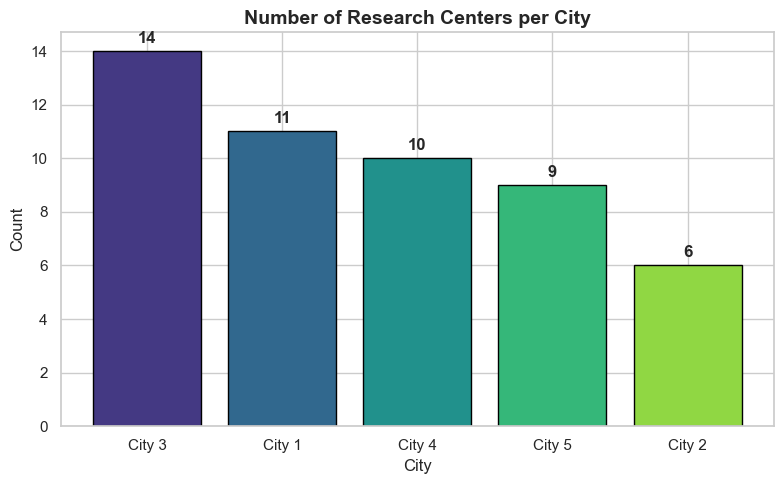

Research centers are distributed across 5 cities.


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
city_counts = df["city"].value_counts()
bars = ax.bar(
    city_counts.index,
    city_counts.values,
    color=sns.color_palette("viridis", len(city_counts)),
    edgecolor="black",
)
ax.set_title("Number of Research Centers per City", fontsize=14, fontweight="bold")
ax.set_xlabel("City")
ax.set_ylabel("Count")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.2,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

print(f"Research centers are distributed across {df['city'].nunique()} cities.")

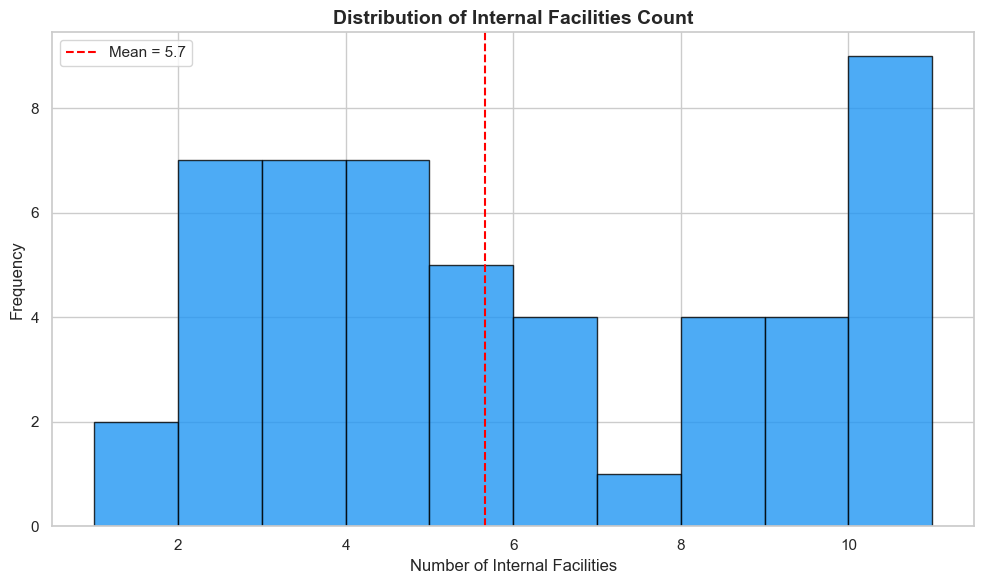

Mean facilities: 5.7
Range: 1 to 11


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(
    df["internalFacilitiesCount"],
    bins=10,
    color="#2196F3",
    edgecolor="black",
    alpha=0.8,
)
ax.set_title("Distribution of Internal Facilities Count", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Internal Facilities")
ax.set_ylabel("Frequency")
ax.axvline(
    df["internalFacilitiesCount"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {df['internalFacilitiesCount'].mean():.1f}",
)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean facilities: {df['internalFacilitiesCount'].mean():.1f}")
print(f"Range: {df['internalFacilitiesCount'].min()} to {df['internalFacilitiesCount'].max()}")

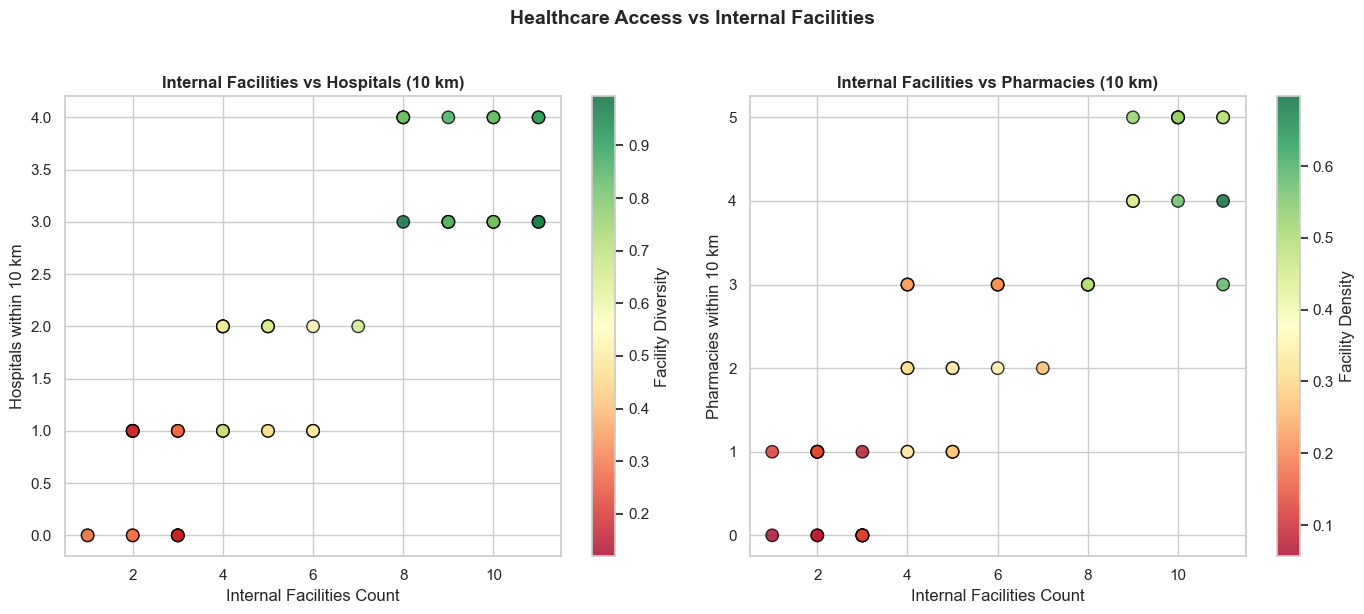

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(
    df["internalFacilitiesCount"],
    df["hospitals_10km"],
    c=df["facilityDiversity_10km"],
    cmap="RdYlGn",
    s=80,
    edgecolor="black",
    alpha=0.8,
)
axes[0].set_title("Internal Facilities vs Hospitals (10 km)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Internal Facilities Count")
axes[0].set_ylabel("Hospitals within 10 km")
plt.colorbar(scatter1, ax=axes[0], label="Facility Diversity")

scatter2 = axes[1].scatter(
    df["internalFacilitiesCount"],
    df["pharmacies_10km"],
    c=df["facilityDensity_10km"],
    cmap="RdYlGn",
    s=80,
    edgecolor="black",
    alpha=0.8,
)
axes[1].set_title("Internal Facilities vs Pharmacies (10 km)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Internal Facilities Count")
axes[1].set_ylabel("Pharmacies within 10 km")
plt.colorbar(scatter2, ax=axes[1], label="Facility Density")

plt.suptitle("Healthcare Access vs Internal Facilities", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [9]:
numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()
candidate_features = [col for col in numeric_columns if col not in ["latitude", "longitude"]]

print("All numeric columns:")
print(numeric_columns)
print("\nCandidate quality-focused numeric features:")
print(candidate_features)

All numeric columns:
['latitude', 'longitude', 'internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km', 'facilityDiversity_10km', 'facilityDensity_10km']

Candidate quality-focused numeric features:
['internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km', 'facilityDiversity_10km', 'facilityDensity_10km']


In [10]:
df[candidate_features].describe().T

,count,mean,std,min,25%,50%,75%,max
internalFacilitiesCount,50.0,5.660000,3.146816,1.000000,3.000000,5.000000,8.750000,11.000000
hospitals_10km,50.0,1.860000,1.340271,0.000000,1.000000,2.000000,3.000000,4.000000
pharmacies_10km,50.0,2.240000,1.684988,0.000000,1.000000,2.000000,3.000000,5.000000
facilityDiversity_10km,50.0,0.568843,0.249511,0.119515,0.344145,0.585503,0.800489,0.992984
facilityDensity_10km,50.0,0.321164,0.182562,0.056541,0.173814,0.297584,0.476387,0.697016


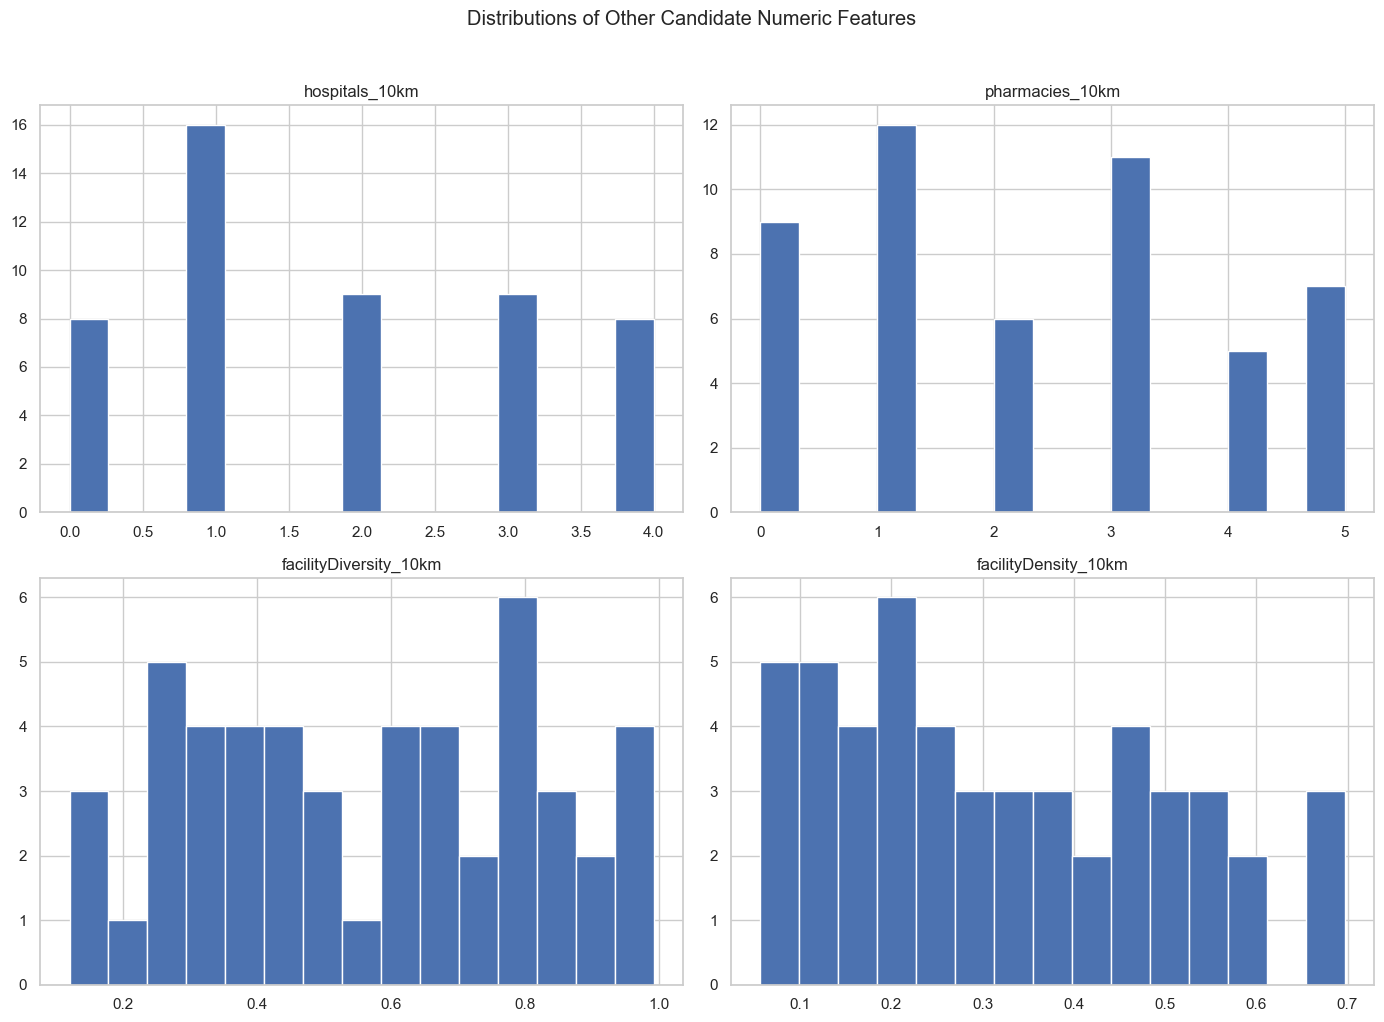

In [11]:
other_candidate_features = [
    feature for feature in candidate_features
    if feature != "internalFacilitiesCount"
]

df[other_candidate_features].hist(figsize=(14, 10), bins=15)
plt.suptitle("Distributions of Other Candidate Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

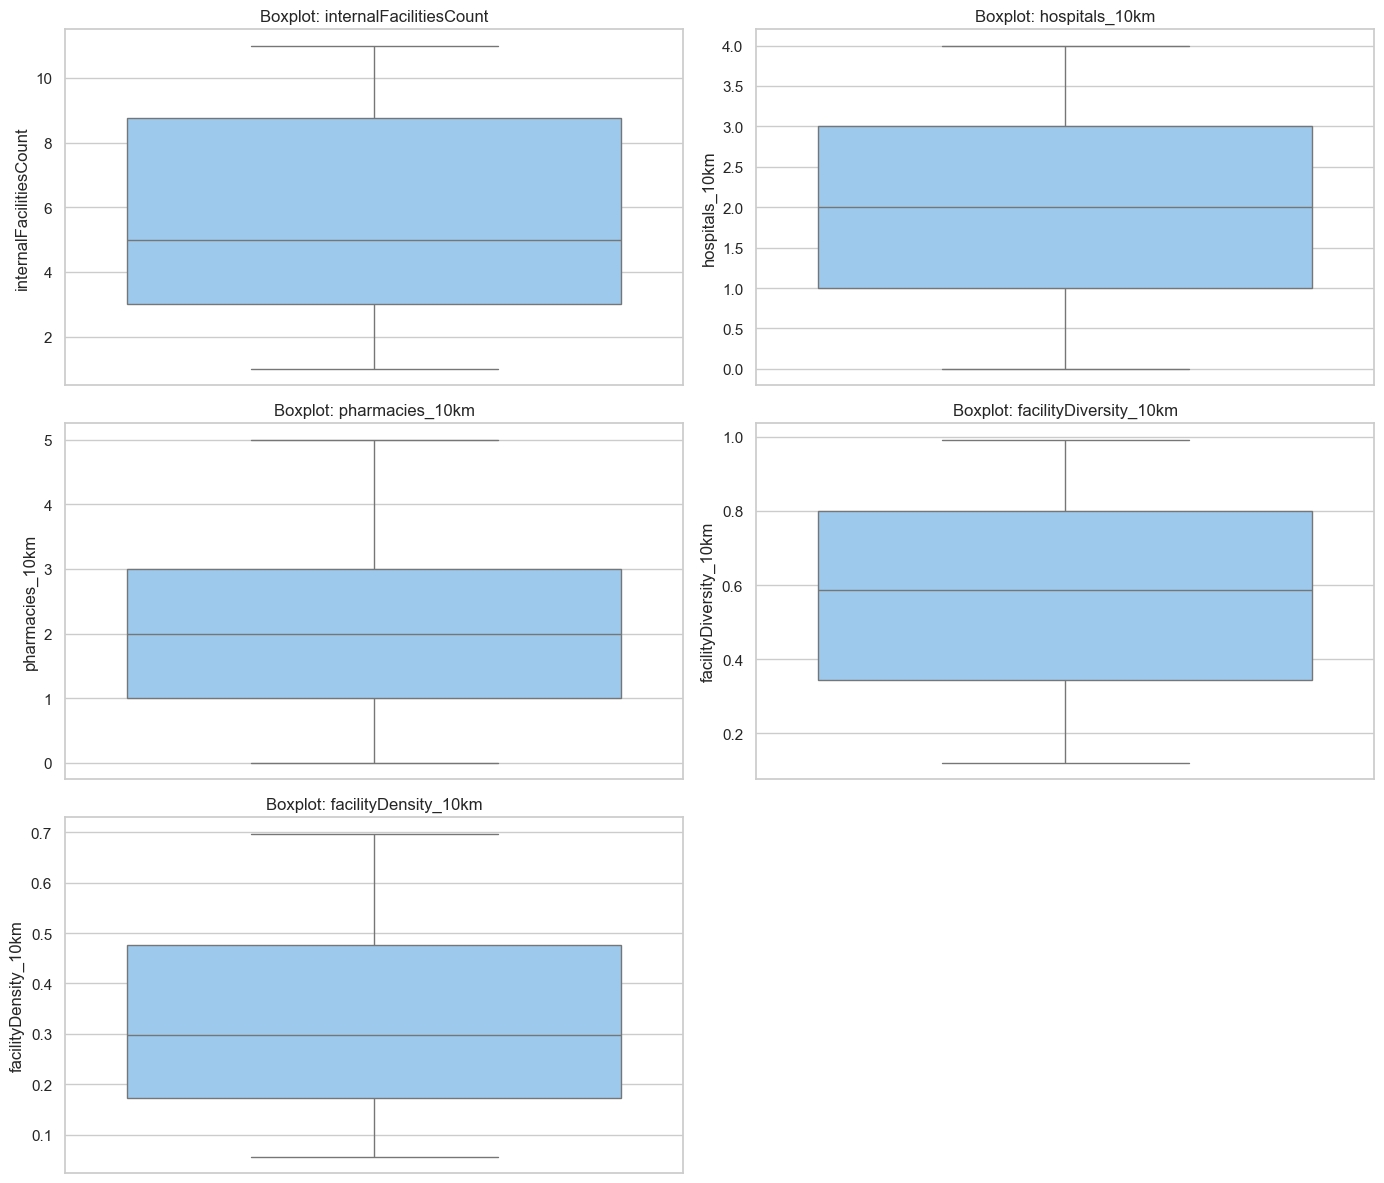

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, feature in enumerate(candidate_features):
    sns.boxplot(y=df[feature], ax=axes[idx], color="#90CAF9")
    axes[idx].set_title(f"Boxplot: {feature}")

if len(candidate_features) < len(axes):
    for idx in range(len(candidate_features), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [13]:
outlier_summary = []

for feature in candidate_features:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df[feature] < lower_bound) | (df[feature] > upper_bound)).sum()

    outlier_summary.append(
        {
            "feature": feature,
            "Q1": round(q1, 3),
            "Q3": round(q3, 3),
            "IQR": round(iqr, 3),
            "lower_bound": round(lower_bound, 3),
            "upper_bound": round(upper_bound, 3),
            "outlier_count": int(outlier_count),
            "outlier_percentage": round((outlier_count / len(df)) * 100, 2),
        }
    )

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values(by="outlier_count", ascending=False)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,internalFacilitiesCount,3.000,8.750,5.750,-5.625,17.375,0,0.0
1,hospitals_10km,1.000,3.000,2.000,-2.000,6.000,0,0.0
2,pharmacies_10km,1.000,3.000,2.000,-2.000,6.000,0,0.0
3,facilityDiversity_10km,0.344,0.800,0.456,-0.340,1.485,0,0.0
4,facilityDensity_10km,0.174,0.476,0.303,-0.280,0.930,0,0.0


## 3. Feature selection

The model should use features that reflect center quality.
Identifier columns, city, and raw coordinates are not used.

The chosen features focus on two things:
internal capability and nearby healthcare support.

### Why these features were selected

The goal is to group research centers using variables that reflect
quality and support. `researchCenterId` and `researchCenterName`
are identifiers, `city` is a descriptive location field, and
`latitude` and `longitude` are coordinates. These fields help with
reference and interpretation, but they are not direct quality measures.

The selected features capture two main ideas:
1. internal capability of the center
2. nearby healthcare support and accessibility

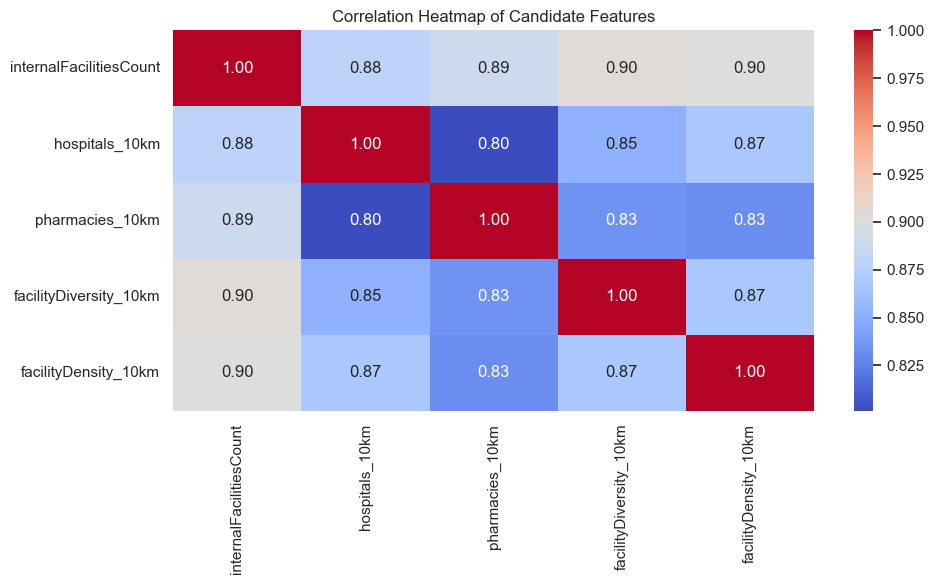

In [14]:
plt.figure(figsize=(10, 6))
corr_matrix = df[candidate_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Candidate Features")
plt.tight_layout()
plt.show()

In [15]:
feature_stats = pd.DataFrame(
    {
        "mean": df[candidate_features].mean(),
        "std_dev": df[candidate_features].std(),
        "variance": df[candidate_features].var(),
    }
)

feature_stats["coef_variation"] = (
    feature_stats["std_dev"] / feature_stats["mean"].replace(0, pd.NA)
)
feature_stats.sort_values(by="variance", ascending=False)

,mean,std_dev,variance,coef_variation
internalFacilitiesCount,5.660000,3.146816,9.902449,0.555975
pharmacies_10km,2.240000,1.684988,2.839184,0.752227
hospitals_10km,1.860000,1.340271,1.796327,0.720576
facilityDiversity_10km,0.568843,0.249511,0.062256,0.438629
facilityDensity_10km,0.321164,0.182562,0.033329,0.568440


In [16]:
excluded_features = [
    "researchCenterId",
    "researchCenterName",
    "city",
    "latitude",
    "longitude",
]
selected_features = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km",
]

print("Excluded features:", excluded_features)
print("Selected features:", selected_features)

Excluded features: ['researchCenterId', 'researchCenterName', 'city', 'latitude', 'longitude']
Selected features: ['internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km', 'facilityDiversity_10km', 'facilityDensity_10km']


In [17]:
pd.DataFrame(
    {
        "selected_feature": selected_features,
        "why_it_matters": [
            "Measures internal research-center capability.",
            "Measures hospital access near the center.",
            "Measures pharmacy access near the center.",
            "Shows variety of nearby facilities.",
            "Shows concentration of nearby support services.",
        ],
    }
)

,selected_feature,why_it_matters
0,internalFacilitiesCount,Measures internal research-center capability.
1,hospitals_10km,Measures hospital access near the center.
2,pharmacies_10km,Measures pharmacy access near the center.
3,facilityDiversity_10km,Shows variety of nearby facilities.
4,facilityDensity_10km,Shows concentration of nearby support services.


## 4. Data standardisation

K-Means is distance-based, so the features need to be
on a similar scale. StandardScaler is used before training.

In [18]:
scaler = StandardScaler()
X = df[selected_features].copy()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features)

print("Before scaling (first 3 rows):")
print(X.head(3).to_string())
print("\nAfter scaling (first 3 rows):")
print(X_scaled_df.head(3).round(3).to_string())
print("\nScaled means:")
print(X_scaled_df.mean().round(4).to_list())
print("Scaled standard deviations:")
print(X_scaled_df.std().round(4).to_list())

Before scaling (first 3 rows):
   internalFacilitiesCount  hospitals_10km  pharmacies_10km  facilityDiversity_10km  facilityDensity_10km
0                        3               1                0                0.374488              0.177506
1                        2               1                1                0.391903              0.108965
2                        3               0                1                0.293552              0.076155

After scaling (first 3 rows):
   internalFacilitiesCount  hospitals_10km  pharmacies_10km  facilityDiversity_10km  facilityDensity_10km
0                   -0.854          -0.648           -1.343                  -0.787                -0.795
1                   -1.175          -0.648           -0.743                  -0.716                -1.174
2                   -0.854          -1.402           -0.743                  -1.115                -1.356

Scaled means:
[-0.0, -0.0, -0.0, 0.0, 0.0]
Scaled standard deviations:
[1.0102, 1.0102, 1

## 5. K-Means clustering

The task asks for three quality tiers, so the model uses `k=3`.
The Elbow Method is shown as a quick check, and silhouette score
is used to judge how well the clusters are separated.

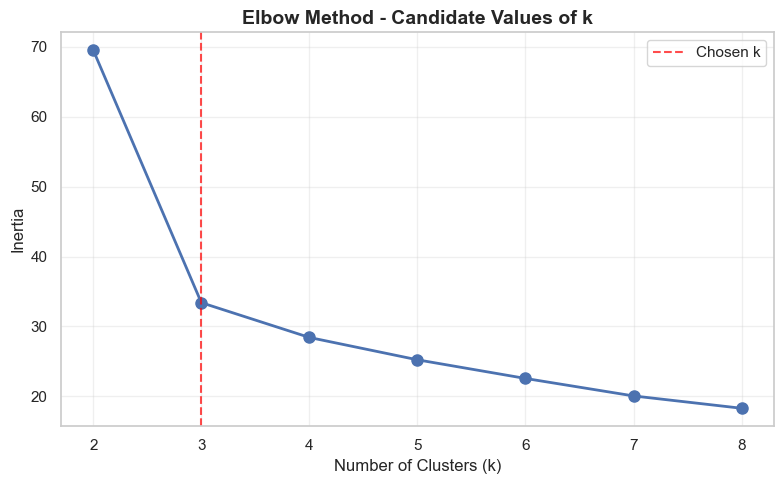

In [19]:
inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertias, "bo-", linewidth=2, markersize=8)
ax.set_title("Elbow Method - Candidate Values of k", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
ax.axvline(x=3, color="red", linestyle="--", alpha=0.7, label="Chosen k")
ax.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_scaled)
silhouette = silhouette_score(X_scaled, cluster_labels)

print("K-Means clustering complete.")
print(f"Silhouette score: {silhouette:.4f}")
print("\nCluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

K-Means clustering complete.
Silhouette score: 0.5519

Cluster distribution:
0    17
1    17
2    16
Name: count, dtype: int64


### 5.1 Cluster-to-tier mapping

K-Means cluster numbers do not have business meaning by themselves.
After training, the clusters are ranked and mapped to
Premium, Standard, and Basic.

In [21]:
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=selected_features)
cluster_strength = cluster_centers.mean(axis=1).sort_values(ascending=False)

tier_labels = ["Premium", "Standard", "Basic"]
cluster_to_tier = {}
for rank, (cluster_id, _) in enumerate(cluster_strength.items()):
    cluster_to_tier[int(cluster_id)] = tier_labels[rank]

results = df.copy()
results["cluster"] = cluster_labels
results["qualityTier"] = results["cluster"].map(cluster_to_tier)

print("Cluster to tier mapping:")
for cluster_id, tier in sorted(cluster_to_tier.items()):
    print(f"Cluster {cluster_id} -> {tier}")

results.head()

Cluster to tier mapping:
Cluster 0 -> Standard
Cluster 1 -> Premium
Cluster 2 -> Basic


,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km,cluster,qualityTier
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506,2,Basic
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965,2,Basic
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155,2,Basic
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016,1,Premium
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983,1,Premium


In [22]:
cluster_profile = (
    results.groupby(["cluster", "qualityTier"])[selected_features]
    .mean()
    .round(3)
    .reset_index()
    .sort_values("qualityTier")
)

city_tier_distribution = pd.crosstab(results["city"], results["qualityTier"])
cluster_profile

,cluster,qualityTier,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
2,2,Basic,2.312,0.500,0.438,0.279,0.125
1,1,Premium,9.529,3.471,4.118,0.850,0.537
0,0,Standard,4.941,1.529,2.059,0.560,0.290


## 6. Model interpretation

This section shows what separates the three tiers,
how they are spread across cities, and which features
create the biggest differences between clusters.

In [23]:
for tier in ["Premium", "Standard", "Basic"]:
    tier_data = results[results["qualityTier"] == tier]
    print("=" * 60)
    print(f"{tier.upper()} TIER ({len(tier_data)} centers)")
    print("=" * 60)
    for feature in selected_features:
        print(f"{feature:30s} | Mean: {tier_data[feature].mean():.3f}")
    print()

PREMIUM TIER (17 centers)
internalFacilitiesCount        | Mean: 9.529
hospitals_10km                 | Mean: 3.471
pharmacies_10km                | Mean: 4.118
facilityDiversity_10km         | Mean: 0.850
facilityDensity_10km           | Mean: 0.537

STANDARD TIER (17 centers)
internalFacilitiesCount        | Mean: 4.941
hospitals_10km                 | Mean: 1.529
pharmacies_10km                | Mean: 2.059
facilityDiversity_10km         | Mean: 0.560
facilityDensity_10km           | Mean: 0.290

BASIC TIER (16 centers)
internalFacilitiesCount        | Mean: 2.312
hospitals_10km                 | Mean: 0.500
pharmacies_10km                | Mean: 0.438
facilityDiversity_10km         | Mean: 0.279
facilityDensity_10km           | Mean: 0.125



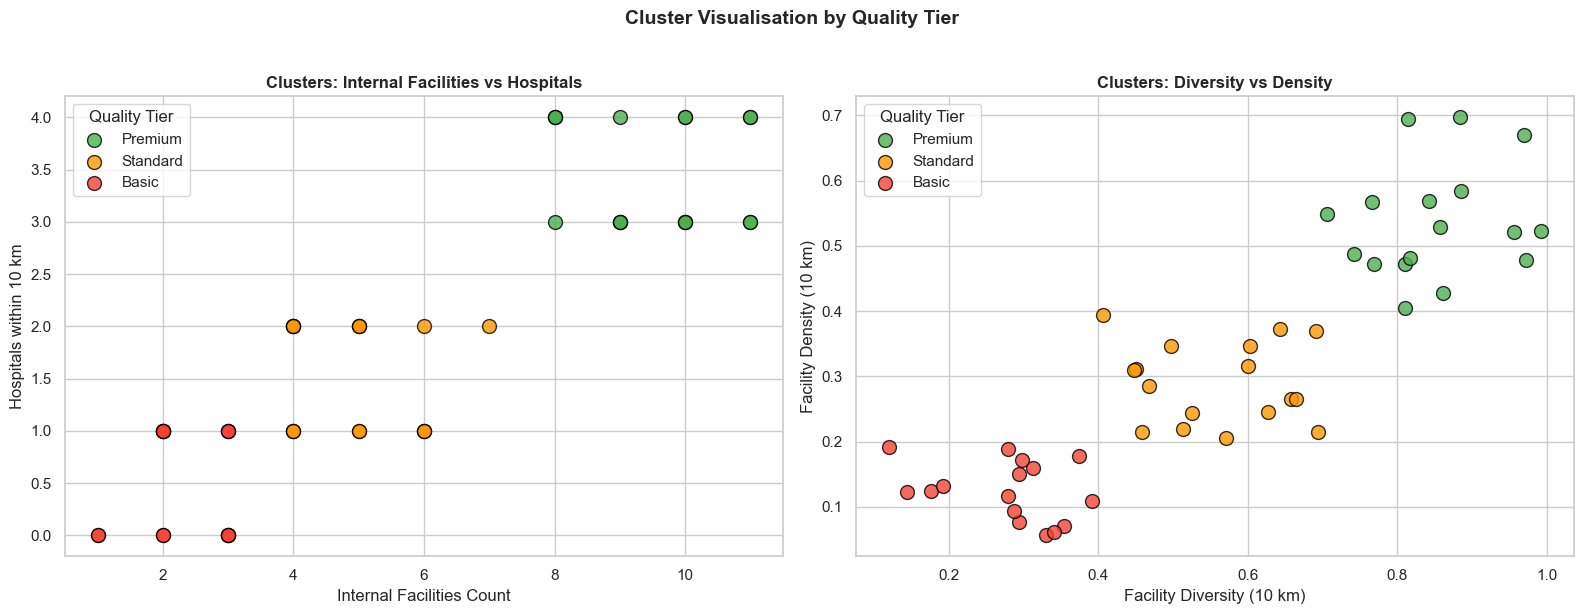

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
tier_colors = {"Premium": "#4CAF50", "Standard": "#FF9800", "Basic": "#F44336"}

for tier, color in tier_colors.items():
    mask = results["qualityTier"] == tier
    axes[0].scatter(
        results.loc[mask, "internalFacilitiesCount"],
        results.loc[mask, "hospitals_10km"],
        c=color,
        label=tier,
        s=100,
        edgecolor="black",
        alpha=0.8,
    )
    axes[1].scatter(
        results.loc[mask, "facilityDiversity_10km"],
        results.loc[mask, "facilityDensity_10km"],
        c=color,
        label=tier,
        s=100,
        edgecolor="black",
        alpha=0.8,
    )

axes[0].set_title("Clusters: Internal Facilities vs Hospitals", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Internal Facilities Count")
axes[0].set_ylabel("Hospitals within 10 km")
axes[0].legend(title="Quality Tier")

axes[1].set_title("Clusters: Diversity vs Density", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Facility Diversity (10 km)")
axes[1].set_ylabel("Facility Density (10 km)")
axes[1].legend(title="Quality Tier")

plt.suptitle("Cluster Visualisation by Quality Tier", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Quality Tier Distribution by City:
qualityTier  Basic  Premium  Standard
city                                 
City 1           1        4         6
City 2           2        2         2
City 3           5        4         5
City 4           5        4         1
City 5           3        3         3


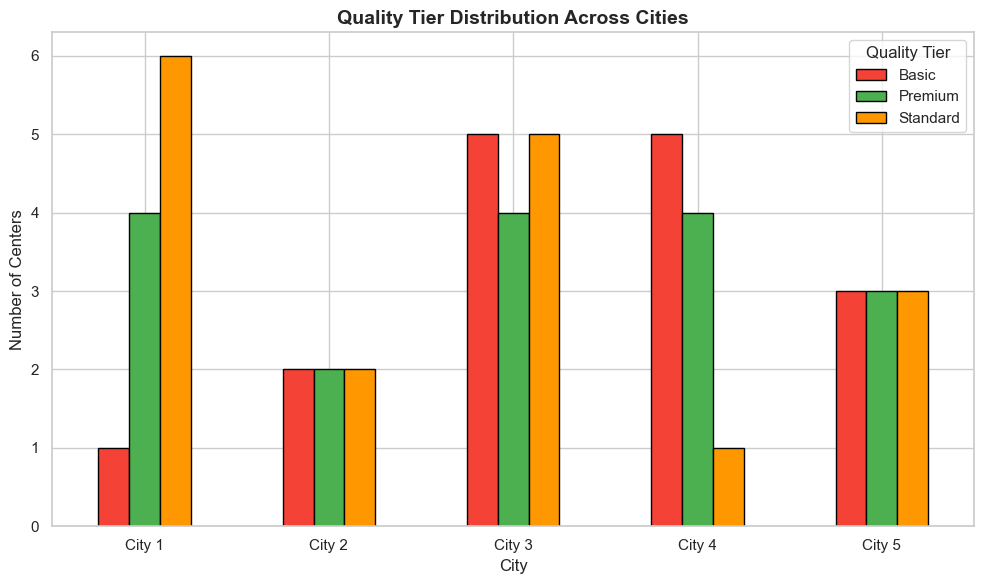

In [25]:
print("Quality Tier Distribution by City:")
print(city_tier_distribution.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
city_tier_distribution.plot(
    kind="bar",
    ax=ax,
    color=["#F44336", "#4CAF50", "#FF9800"],
    edgecolor="black",
)
ax.set_title("Quality Tier Distribution Across Cities", fontsize=14, fontweight="bold")
ax.set_xlabel("City")
ax.set_ylabel("Number of Centers")
ax.legend(title="Quality Tier")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Feature importance based on centroid separation:
internalFacilitiesCount    2.317
facilityDiversity_10km     2.313
facilityDensity_10km       2.277
hospitals_10km             2.239
pharmacies_10km            2.206


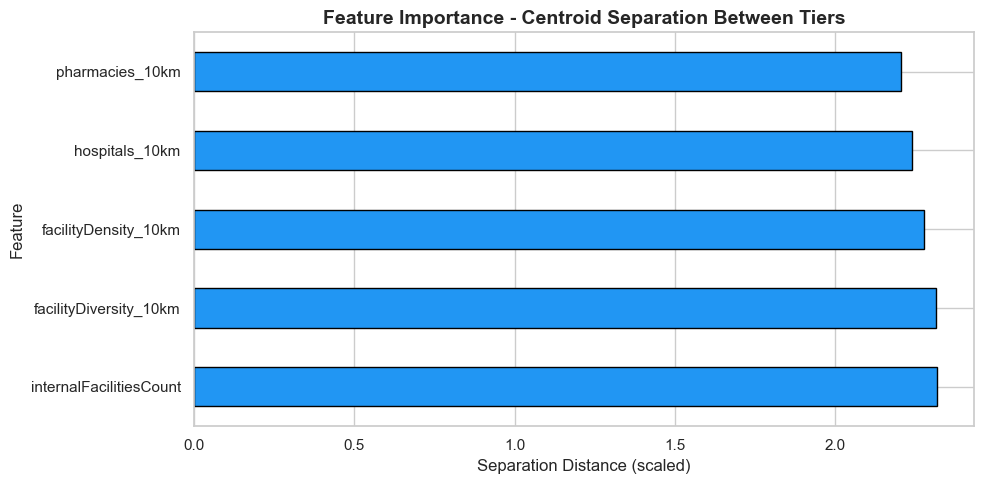

In [26]:
centroid_df = pd.DataFrame(kmeans.cluster_centers_, columns=selected_features)
centroid_df.index = [cluster_to_tier[i] for i in range(3)]

feature_importance = (centroid_df.max() - centroid_df.min()).sort_values(ascending=False)

print("Feature importance based on centroid separation:")
print(feature_importance.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
feature_importance.plot(kind="barh", ax=ax, color="#2196F3", edgecolor="black")
ax.set_title("Feature Importance - Centroid Separation Between Tiers", fontsize=14, fontweight="bold")
ax.set_xlabel("Separation Distance (scaled)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## 7. Save artefacts

The trained model and summary files are saved here
so the FastAPI app can use the same outputs.

In [27]:
ARTIFACT_DIR.mkdir(exist_ok=True)

cluster_strength_lookup = {
    int(cluster_id): float(score)
    for cluster_id, score in cluster_centers.mean(axis=1).sort_values().items()
}

model_bundle = {
    "model": kmeans,
    "scaler": scaler,
    "selected_features": selected_features,
    "cluster_to_tier": cluster_to_tier,
    "cluster_strength": cluster_strength_lookup,
    "metrics": {"silhouette_score": round(float(silhouette), 4)},
}

joblib.dump(model_bundle, "cluster_model.pkl")
results.to_csv(ARTIFACT_DIR / "research_centers_clustered.csv", index=False)
cluster_profile.to_csv(ARTIFACT_DIR / "cluster_profile.csv", index=False)
city_tier_distribution.to_csv(ARTIFACT_DIR / "city_tier_distribution.csv", index=False)
(ARTIFACT_DIR / "metrics.json").write_text(
    json.dumps(model_bundle["metrics"], indent=2),
    encoding="utf-8",
)

print("Saved cluster_model.pkl")
print("Saved artifacts/research_centers_clustered.csv")
print("Saved artifacts/cluster_profile.csv")
print("Saved artifacts/city_tier_distribution.csv")
print("Saved artifacts/metrics.json")

Saved cluster_model.pkl
Saved artifacts/research_centers_clustered.csv
Saved artifacts/cluster_profile.csv
Saved artifacts/city_tier_distribution.csv
Saved artifacts/metrics.json


## Summary and conclusions

- The workflow covers data checks, EDA, feature selection,
  scaling, clustering, interpretation, and saved outputs.
- The selected features describe internal capability
  and nearby healthcare support.
- The final K-Means solution achieved a silhouette score
  of 0.5519, which suggests reasonably clear separation.
- Premium centers average 9.53 internal facilities,
  compared with 2.31 in Basic centers.
- The saved files are reused by `app.py` for prediction.

## Optional improvement idea

One simple way to improve the silhouette score is to reduce
redundancy in the feature set. The correlation analysis showed
that `pharmacies_10km` is strongly aligned with the other
nearby-support variables, so it is a reasonable candidate to drop
in an alternative experiment.

This does **not** replace the main submission model. It is included
here as a small sensitivity check. The main submission keeps the
five-feature baseline for consistency and interpretability.

In [28]:
improvement_features = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km",
]

X_improved = df[improvement_features].copy()
X_improved_scaled = StandardScaler().fit_transform(X_improved)

kmeans_improved = KMeans(n_clusters=3, random_state=42, n_init=20)
improved_labels = kmeans_improved.fit_predict(X_improved_scaled)
improved_silhouette = silhouette_score(X_improved_scaled, improved_labels)

comparison = pd.DataFrame(
    {
        "model_version": [
            "Baseline (5 features)",
            "Alternative (4 features)",
        ],
        "features_used": [
            ", ".join(selected_features),
            ", ".join(improvement_features),
        ],
        "silhouette_score": [
            round(float(silhouette), 4),
            round(float(improved_silhouette), 4),
        ],
    }
)

comparison

,model_version,features_used,silhouette_score
0,Baseline (5 features),"internalFacilitiesCount, hospitals_10km, pharm...",0.5519
1,Alternative (4 features),"internalFacilitiesCount, hospitals_10km, facil...",0.5716


The alternative four-feature version reaches a silhouette score of
about **0.5716**, compared with **0.5519** for the baseline.

This suggests that removing a redundant feature can slightly
improve cluster separation, even when the baseline model is
already reasonable.